In [206]:
# 5-3 housing

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/house_train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [207]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [208]:
tmp = df.isnull().sum()
print(tmp[tmp > 0].sort_values(ascending = False))
# null이 얼마나 있는지 찾아보기

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


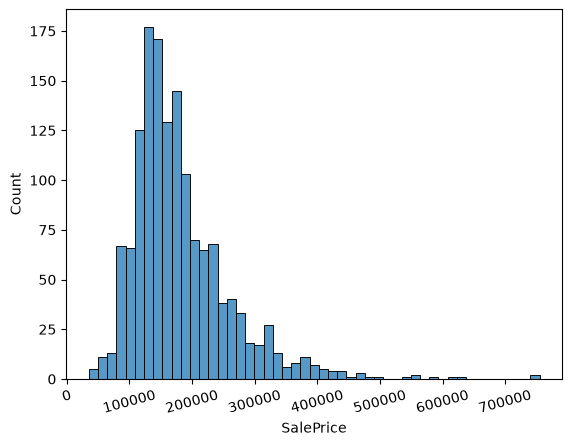

In [209]:
plt.xticks(rotation = 15)
sns.histplot(df["SalePrice"])
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

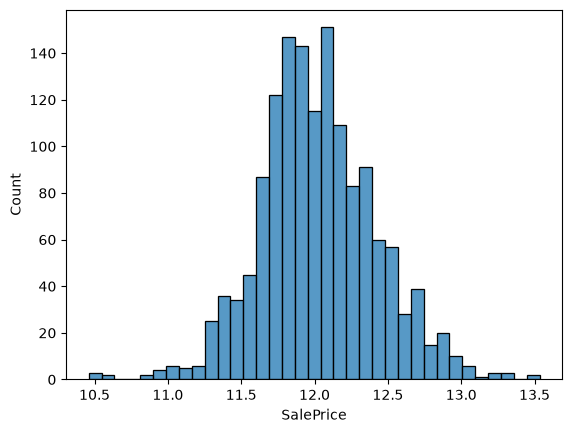

In [210]:
log_SalePrice = np.log1p(df["SalePrice"])

sns.histplot(log_SalePrice)
# 분포가 가운데로 옮겨짐

In [211]:
df["FireplaceQu"].value_counts() # 1400개 중에 절반이 결측치
# 최빈값 <- Gd의 영향이 너무커짐
# 평균 <- str이라 불가능

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [212]:
# PoolQC          1453
# MiscFeature     1406
# Alley           1369
# Fence           1179
# MasVnrType       872
# FireplaceQu      690

# 위 결측치들 처리를 해야함.

drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "Id"]

# 결측치 많은 칼럼 드랍
df = df.drop(drop_cols, axis = 1)

# 숫자 칼럼의 경우 결측치를 평균으로 대체
num_cols = df.dtypes[df.dtypes != "str"].index # info()찍고 확인해서 날려야됨.

# 데이터타입 : Object의 경우 여전히 결측치 존재
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 남아있는 null칼럼 보기
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

GarageQual      81
GarageCond      81
GarageFinish    81
GarageType      81
BsmtFinType2    38
BsmtExposure    38
BsmtCond        37
BsmtQual        37
BsmtFinType1    37
Electrical       1
dtype: int64


In [213]:
y = df["SalePrice"]
X = df.drop(["SalePrice"], axis = 1)

print(y.shape)
print(X.shape)

(1460,)
(1460, 73)


In [214]:
from sklearn.model_selection import train_test_split

X_dum = pd.get_dummies(X)

X_train, X_val, y_train, y_val = train_test_split(X_dum, y, test_size = 0.3, random_state = 42)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(1022, 266) (438, 266) (1022,) (438,)


In [215]:
# XGB, LGBM 쓰기

# test셋 전처리 하기.

df_test = pd.read_csv("../data/house_test.csv")

df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [216]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [217]:
# test도 똑같이
# 결측치 많은 칼럼 드랍
id = df_test["Id"]

df_test = df_test.drop(drop_cols, axis = 1)

# 숫자 칼럼의 경우 결측치를 평균으로 대체
num_cols = df_test.dtypes[df.dtypes != "str"].index # info()찍고 확인해서 날려야됨.

# 데이터타입 : Object의 경우 여전히 결측치 존재
df_test[num_cols] = df_test[num_cols].fillna(df_test[num_cols].mean())

# 남아있는 null칼럼 보기
print(df_test.isnull().sum()[df_test.isnull().sum() > 0].sort_values(ascending=False))


GarageCond      78
GarageFinish    78
GarageQual      78
GarageType      76
BsmtCond        45
BsmtQual        44
BsmtExposure    44
BsmtFinType1    42
BsmtFinType2    42
MSZoning         4
Utilities        2
Functional       2
Exterior1st      1
Exterior2nd      1
KitchenQual      1
SaleType         1
dtype: int64


In [218]:
X_test = df_test
X_test_dum = pd.get_dummies(X_test)

X_test_dum = X_test_dum.reindex(columns = X_train.columns, fill_value = 0) # train셋에 맞춰서 reindex 해줘야함

print(y.shape)
print(X_train.shape, X_test_dum.shape)

(1460,)
(1022, 266) (1459, 266)


In [219]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

xgb_reg = XGBRegressor(n_estimators = 500, learning_rate = 0.02, subsample = 0.8, max_depth = 5, colsample_bytree = 0.5)
lgbm_reg = LGBMRegressor(n_estimators = 500, learning_rate = 0.02, colsample_bytree = 0.5, verbose = -1, n_jobs = -1)

# XGBOOST
xgb_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_val)
print("XGB 모델 예측값:", xgb_pred)

xgb_mse = mean_squared_error(y_val, xgb_pred)
print("XGB 모델 MSE:", xgb_mse)

xgb_rmse = np.sqrt(xgb_mse)
print("XGB 모델 RMSE:", xgb_rmse)

XGB 모델 예측값: [140834.75  340027.38  119219.84  153155.44  329800.97   81217.99
 226857.42  147258.33   85665.695 134683.92  148170.34  122075.78
 113588.734 202848.45  167452.02  132341.31  193977.39  129713.98
 121525.4   217270.12  171881.42  226575.48  174228.25  128231.47
 201578.08  173515.77  198424.16  108743.53  176242.56  195118.19
 122522.69  258991.4   211431.31  110314.41  256457.61  147937.44
 133072.39  206517.7   311979.    111480.54  130719.35  236455.67
 120473.945 368638.47  131601.42  141536.38  113204.99  127849.42
 396042.25  135999.61  123456.38  205812.61  116596.19  327631.62
 146276.95  248128.3   197764.16  150915.12  138939.64  110045.84
  69927.56  155193.    310709.38  277118.25  291601.03  220761.92
 111462.85  327319.16  107220.52  163971.45  123618.04  127534.51
 111030.3    87868.8   473651.53  182091.78  313319.88  315067.84
 138775.95  122764.65  110204.69   76506.95  120140.03  100487.06
 156783.23  136162.94  262422.44  205955.61  142722.23  180935.7

In [220]:
# LightGBM

lgbm_reg.fit(X_train, y_train)
lgbm_pred = lgbm_reg.predict(X_val)
print("LGBM 모델 예측값:", lgbm_pred)

lgbm_mse = mean_squared_error(y_val, lgbm_pred)
print("LGBM 모델 MSE:", lgbm_mse)

lgbm_rmse = np.sqrt(lgbm_mse)
print("LGBM 모델 RMSE:", lgbm_rmse)

LGBM 모델 예측값: [144892.57578752 293450.5648282  110840.58176925 150257.49326872
 334251.35818965  74915.08519549 222283.88178507 146261.91575368
  79115.80775777 131732.12347035 146099.8143474  118792.78749273
 130334.55103405 196959.5843537  171687.78683054 131374.37798905
 189381.69911294 132551.49249427 126138.70868395 212898.64252275
 170840.93531309 236062.50297025 180092.64886429 130902.16425957
 200199.28012115 168491.42981797 198525.23090211 102432.39047125
 179705.57892959 205042.36460748 124270.10663134 260401.55083374
 183839.10184032 114187.5081659  260521.85986959 148477.80102928
 137421.85941451 201739.54042047 325292.00880969 112397.17840767
 128336.42015877 235168.69116688 117379.46610811 376566.76242928
 127594.24826972 137961.91105328 118319.35144958 124243.99939013
 435103.664688   140358.32693472 122269.65198136 207776.99322403
 116113.2918202  365488.17364099 146158.08762753 252294.98730045
 202164.62406266 153450.96282306 132066.20299297 113658.34263627
  69239.9499

In [221]:
print("#" * 10 + "각 모델 결과" + "#" * 10)
print("XGB RMSE:", xgb_rmse)
print("LGBM RMSE:", lgbm_rmse)

##########각 모델 결과##########
XGB RMSE: 23037.16093619177
LGBM RMSE: 25572.872033552223


In [222]:
y_pred_xgb = xgb_reg.predict(X_test_dum)
y_pred_lgbm = lgbm_reg.predict(X_test_dum)

print(y_pred_lgbm.shape, y_pred_xgb.shape)
print(type(y_pred_lgbm), type(y_pred_xgb))

house_pred = pd.DataFrame({"Id": id, "XGB Predict": y_pred_xgb, "LGBM Predict": y_pred_lgbm})

house_pred.to_csv("../data/house_pred.csv", index = False)


(1459,) (1459,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
